In [1]:
import numpy as np
from scipy import fft
import scipy as sp
from scipy import signal
from matplotlib import pyplot as plt
from matplotlib import patches

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# https://wirelesspi.com/a-visualization-of-causality-and-stability-in-z-transform/

-----


# Z-Transform for Digital Filters


The Z-transform can be used to investigate the properties (e.g. the stability) of discrete time LTI systems,
such as FIR and IIR filters.
This is achieved by applying the transform to the filter coefficients, similar to the Lplace transform on the impulse response of a continuous time system.

## Transfer Function



In general, the transfer function of a system describes the relation between input and output.
Considering the Z-Transform, this means:

$$
H(z) = \frac{Y(z)}{X(z)} = \frac{\mathcal Z\{y[n]\}}{\mathcal Z\{x[n]\}}
$$


## Difference Equation

We know the difference equation of a digital filter can be expressed with two sums - one for forward and one for recirsive coefficients:

$$
   y[n] =  \sum\limits_{i=0}^{i=N} b_i  x[n-i] - \sum\limits_{i=1}^{i=N} a_i  y[n-i]
$$

## Transform

The transfer function of the filter can be obtained via the z-transform:

$$\begin{eqnarray}
Y(z) & = & X(z) \sum\limits_{i=0}^{i=N} b_i  z^{-i} - Y(z) \sum\limits_{i=1}^{i=N} a_i  z^{-i} \\
\end{eqnarray}
$$

$$\begin{eqnarray}
Y(z) + Y(z) \sum\limits_{i=1}^{i=N} a_i  z^{-i} & = & X(z) \sum\limits_{i=0}^{i=N} b_i  z^{-i}  \\
\end{eqnarray}
$$


$$\begin{eqnarray}
H(z) = \frac{ X(z) \sum\limits_{i=0}^{i=N} b_i  z^{-i}}{1 + Y(z) \sum\limits_{i=1}^{i=N} a_i  z^{-i}}  \\
\end{eqnarray}
$$

$$
H(z)  = \frac{\sum\limits_{n=0}^{n=N} b_n  z^{-n}}{1 +\sum\limits_{n=1}^{n=N} a_n  z^{-n}}
$$


 <div class="alert alert-block alert-warning">
⚠️ Based on variations in the definition of difference fuctions, the transfer functions also result in different signs for  $a_i z^{-1}$. This version is based on Julius Smith.
 </div>

<!-- ------

# 2nd Order IIR Example

With the sum equation above, the Z transform of a second order IIR filter becomes:

$$
H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 - a_1 z^{-1} - a_2 z^{-2}}
$$

We are now expanding with $z^{2}$ to get rid of negative exponents:

$$
H(z) = \frac{b_0 z^{2} + b_1 z^{1} + b_2 }{z^{2} - a_1 z^{1} - a_2}
$$ -->

---

# FIR Example

This example shows how the z-transform can be used to analyse a digital filter.
We are considering an FIR filter with the following difference equation:

$$
y[n] = x[n] + 2 x[n-1] + x[n-2]
$$


The z-transform of this filter is:

$$
H(z) = \frac{z^{0} +  2 z^{-1} +  z^{-2}}{1}  
$$

There is no feedback - hence no $a_i$. However, we need the devision by $1$ for the next steps.

In the next step, all exponents are shifted by expanding with $z^{2}$ to have only positive exponents:

$$
H(z) = \frac{z^2 + 2z + 1}{z^2}
$$

We now have a fraction with two polynoms. To analyse the filter, we are observing:

- **Poles**: when the denominator becomes $0$
- **Zeros**: when the nominator becomes $0$

Factor the denominator to find its roots:


$$
H(z) = \frac{(z+1)(z+1)}{z^2}
$$

As all causal FIR filters it has $N=2$ poles at the origin $z=0$.

**There is a double zero at $\mathbf{z=-1}$**:

----

# In the Z-Plane

The Z-Plane is the time-discrete counterpart to the S-Plane for the Laplace transform.
It shows the complex variable $z$ with its real and imaginary component.

The poles and zeros for the above filter are plotted below.
This can be interpreted as follows:
The magnitude of the transfer function will be large for values of $z$ closer to the poles and smaller for $z$ in near the zeros.

The pole-zero plot also gives information on the stability of the filter:
**A system is stable if all poles are inside the unit circle.**

Since this is an FIR filter, it has to be stable.


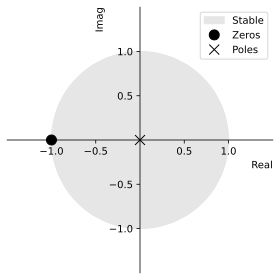

In [10]:
ax = plt.subplot(111)
ax.axis('equal')

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

r = 1.5; plt.axis('scaled'); plt.axis([-r, r, -r, r])
ticks = [-1, -.5, .5, 1]; plt.xticks(ticks); plt.yticks(ticks)

uc = patches.Circle((0,0), radius=1, fill='gray', color='gray', alpha=0.2, label='Stable')


ax.add_patch(uc)


b, a, k = signal.butter(2, 0.1, output='zpk')
 
a[0] *= 2   
    
# zeros
z  = np.roots(b)
t1 = plt.plot(z.real, z.imag, 'ok', ms=10, label='Zeros')

# poles
p  = np.roots(a)
t2 = plt.plot(0, 0, 'xk', ms=10, label='Poles')



plt.xlabel('Real', loc='right')
plt.ylabel('Imag', loc='top')

plt.legend(loc=1);



